In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2341, 211)
X_test shape: (586, 211)


In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Model trained")

Model trained


Linear Regression is essentially a machine learning algorithm used to find the best-fitting line through a scatter plot of data points to help make predictions

In [10]:
y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Baseline")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Linear Regression Baseline
RMSE: 0.0985
MAE:  0.0737
R²:   0.9460


RMSE = Root mean Squared Error (Used to measure the difference between the predicted values by the model, and the actual values)
MAE = it is a standard metric used to evaluate regression models. It calculates the average magnitude of errors between predicted and actual values.
R^2 = it is another metric used in regression models used to indicate the proportion of variance in the target variable that the model explains (from 0% - 100%, the higher the percentage, the better the model predictions)

In [11]:
y_pred_dollars = np.expm1(y_pred)
y_test_dollars = np.expm1(y_test)

rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"In actual dollars:")
print(f"RMSE: ${rmse_dollars:,.0f}")
print(f"MAE:  ${mae_dollars:,.0f}")

In actual dollars:
RMSE: $18,414
MAE:  $12,999


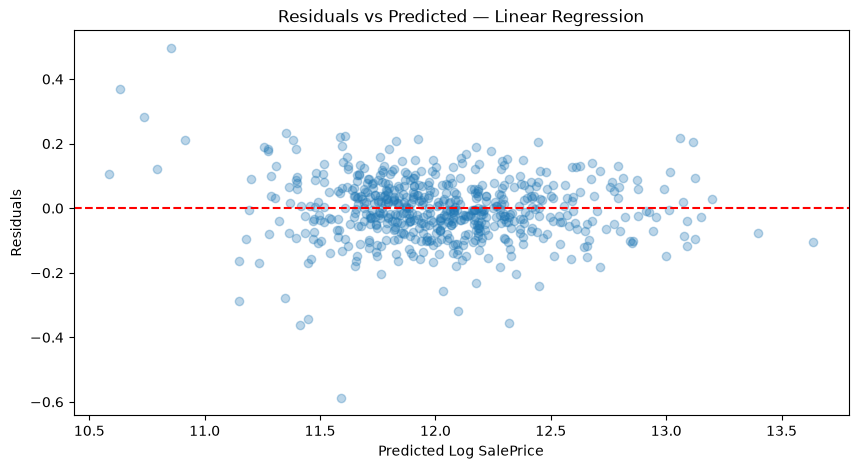

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Log SalePrice')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted — Linear Regression')
plt.show()

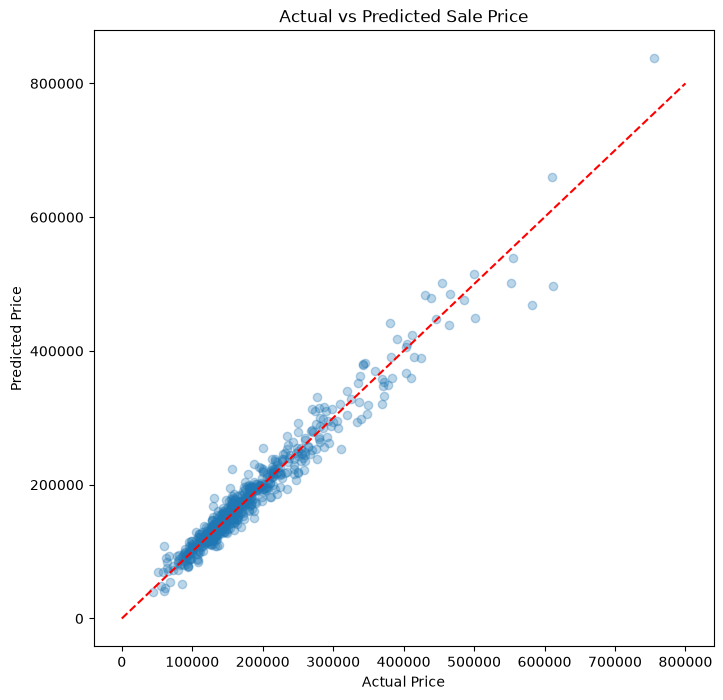

In [13]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_dollars, y_pred_dollars, alpha=0.3)
plt.plot([0, 800000], [0, 800000], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Sale Price')
plt.show()

## Baseline Results — Linear Regression

| Metric | Log Scale | Dollar Scale |
|--------|-----------|--------------|
| RMSE   | 0.0985    | $18,414      |
| MAE    | 0.0737    | $12,999      |
| R²     | 0.9460    | —            |

Strong baseline. R² of 0.946 means the model explains 94.6% of price 
variance

In [14]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.40655
[100]	validation_0-rmse:0.10464
[200]	validation_0-rmse:0.10075
[300]	validation_0-rmse:0.10072
[329]	validation_0-rmse:0.10087


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [15]:
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

y_pred_xgb_dollars = np.expm1(y_pred_xgb)

rmse_xgb_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_xgb_dollars))
mae_xgb_dollars = mean_absolute_error(y_test_dollars, y_pred_xgb_dollars)

print(f"XGBoost Results")
print(f"RMSE: {rmse_xgb:.4f}  (baseline: 0.0985)")
print(f"MAE:  {mae_xgb:.4f}  (baseline: 0.0737)")
print(f"R²:   {r2_xgb:.4f}  (baseline: 0.9460)")
print(f"\nIn actual dollars:")
print(f"RMSE: ${rmse_xgb_dollars:,.0f}  (baseline: $18,414)")
print(f"MAE:  ${mae_xgb_dollars:,.0f}  (baseline: $12,999)")

XGBoost Results
RMSE: 0.1005  (baseline: 0.0985)
MAE:  0.0725  (baseline: 0.0737)
R²:   0.9437  (baseline: 0.9460)

In actual dollars:
RMSE: $21,407  (baseline: $18,414)
MAE:  $13,341  (baseline: $12,999)


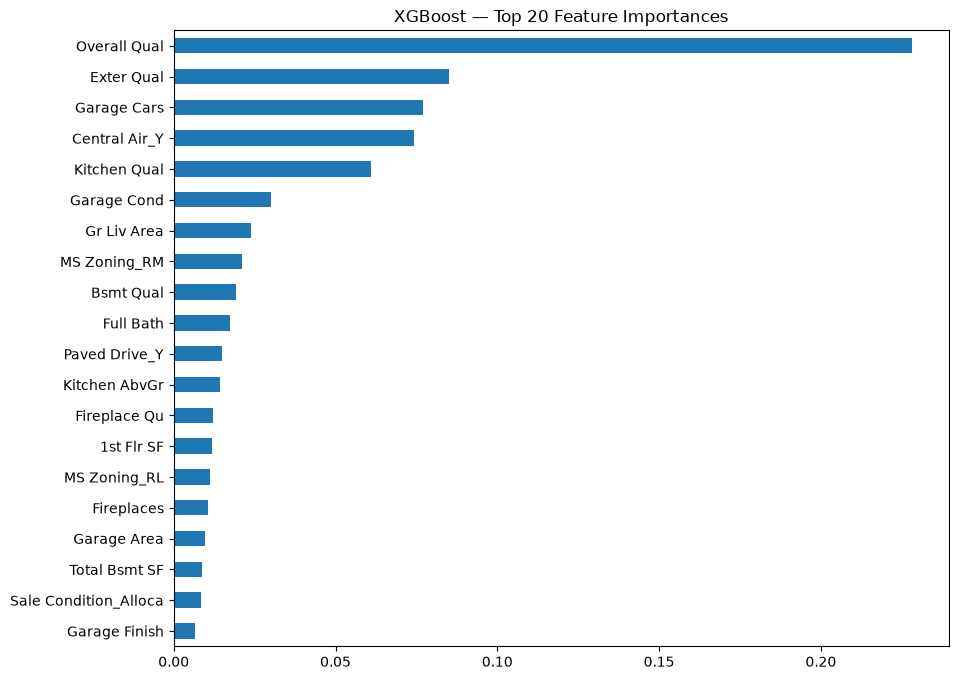

Overall Qual     0.228099
Exter Qual       0.084977
Garage Cars      0.077120
Central Air_Y    0.074132
Kitchen Qual     0.061083
Garage Cond      0.030152
Gr Liv Area      0.023837
MS Zoning_RM     0.021035
Bsmt Qual        0.019358
Full Bath        0.017286
dtype: float32


In [16]:
feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh')
plt.title('XGBoost — Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

print(feat_imp.head(10))

In [ ]:
from sklearn.model_selection import cross_val_score

# Test a range of key parameters
params_to_try = [
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 4},
    {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 4},
    {'n_estimators': 1000, 'learning_rate': 0.01, 'max_depth': 3},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 3},
]

for params in params_to_try:
    model = XGBRegressor(
        **params,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='rmse'
    )
    scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_root_mean_squared_error',
        cv=5
    )
    print(f"Params: {params}")
    print(f"CV RMSE: {-scores.mean():.4f} (+/- {scores.std():.4f})\n")

In [ ]:
xgb_tuned = XGBRegressor(
    n_estimators=500,      # replace with best from above
    learning_rate=0.01,    # replace with best from above
    max_depth=3,           # replace with best from above
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse'
)

xgb_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_tuned.predict(X_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

y_pred_tuned_dollars = np.expm1(y_pred_tuned)
rmse_tuned_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_tuned_dollars))
mae_tuned_dollars = mean_absolute_error(y_test_dollars, y_pred_tuned_dollars)

print(f"Tuned XGBoost Results")
print(f"RMSE: {rmse_tuned:.4f}  (baseline: 0.0985)")
print(f"MAE:  {mae_tuned:.4f}  (baseline: 0.0737)")
print(f"R²:   {r2_tuned:.4f}  (baseline: 0.9460)")
print(f"\nIn actual dollars:")
print(f"RMSE: ${rmse_tuned_dollars:,.0f}  (baseline: $18,414)")
print(f"MAE:  ${mae_tuned_dollars:,.0f}  (baseline: $12,999)")